# General Risk Classifier (Random Forest)

## Business Value
Hospitals need to know which machines are becoming a financial or operational liability over time. 
This Random Forest model acts as the hospital administrator doing a long-term performance review of the equipment. 
It analyzes the lifetime historical and financial statistics of a medical device (e.g., Age, Total Downtime, Mean Time Between Failures (MTBF), and Maintenance Cost Per Hour) and categorizes the equipment into a broad risk tier: Low Risk, Medium Risk, or High Risk.

Because the Random Forest is highly explainable, if it flags an MRI machine as "High Risk," it can generate a feature importance report that explicitly tells the hospital administrator exactly why (e.g., "This machine is classified as High Risk because its Maintenance Cost Per Hour is too high and its MTBF is dropping").


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score


In [2]:
DATA_PATH = "../data/processed/processed_device_level.csv"
TARGET_COL = "Risk_Class_Label"

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
display(df.head())


Shape: (4149, 20)


,Device_ID,Device_Type,Purchase_Date,Age,Manufacturer,Model,Country,Maintenance_Cost,Downtime,Maintenance_Frequency,Failure_Event_Count,Maintenance_Class,Maintenance_Report,Operational_Hours_Est,Expected_Lifespan_Est,MTBF,Cost_Per_Hour,Lifespan_Usage_Ratio,Risk_Class,Risk_Class_Label
0,MD03449,Defibrillator,2018-04-23,7,CardioSync,Model-100,France,7115.349585,7.933824,3,0,1,Component component upgrade after detecting ov...,61320,12,26280.0,0.116036,0.583333,Low Risk,0
1,MD02024,Infusion Pump,2020-12-10,5,MedEquip,Model-650,Italy,7290.780658,7.838711,3,4,2,battery wear caused operational delay; replace...,43800,12,10950.0,0.166456,0.416667,Medium Risk,1
2,MD04239,MRI Scanner,2023-11-22,2,ImagingTech,Model-650,France,5635.521788,13.911045,1,2,3,data lag caused operational delay; component u...,17520,12,8760.0,0.321662,0.166667,Medium Risk,1
3,MD00153,Defibrillator,2021-03-03,4,RescueTech,Model-450,UK,5001.360188,28.996465,3,1,3,Routine check completed; battery wear observed...,35040,12,35040.0,0.142733,0.333333,Medium Risk,1
4,MD03743,Defibrillator,2019-05-16,6,RescueTech,Model-450,Canada,7555.132928,13.942355,4,4,2,Component inspection after detecting voltage s...,52560,12,13140.0,0.143743,0.500000,Medium Risk,1


In [3]:
# Drop obvious ID-like or duplicate-target columns for modeling.
drop_cols = ["Device_ID", "Risk_Class", "Maintenance_Report", "Purchase_Date"]
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=[TARGET_COL] + drop_cols)
y = df[TARGET_COL]

print("Target distribution:")
print(y.value_counts(normalize=True).sort_index())
print("\nFeature columns:")
print(X.columns.tolist())


Target distribution:
Risk_Class_Label
0    0.141721
1    0.742830
2    0.115450
Name: proportion, dtype: float64

Feature columns:
['Device_Type', 'Age', 'Manufacturer', 'Model', 'Country', 'Maintenance_Cost', 'Downtime', 'Maintenance_Frequency', 'Failure_Event_Count', 'Maintenance_Class', 'Operational_Hours_Est', 'Expected_Lifespan_Est', 'MTBF', 'Cost_Per_Hour', 'Lifespan_Usage_Ratio']


In [4]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("Prepared train shape:", X_train_prepared.shape)
print("Ready for Random Forest training.")


Prepared train shape: (3319, 41)
Ready for Random Forest training.


Training Random Forest General Risk Classifier...


Accuracy: 0.9988

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       118
           1       1.00      1.00      1.00       616
           2       1.00      0.99      0.99        96

    accuracy                           1.00       830
   macro avg       1.00      1.00      1.00       830
weighted avg       1.00      1.00      1.00       830



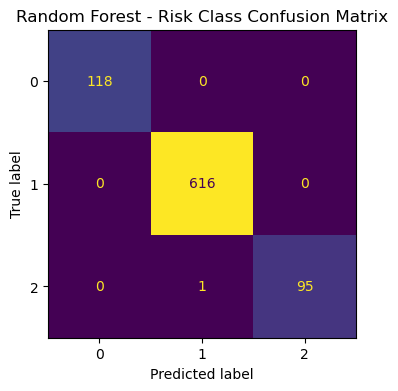

In [6]:
rf_classifier = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)

print("Training Random Forest General Risk Classifier...")
rf_classifier.fit(X_train_prepared, y_train)

y_pred = rf_classifier.predict(X_test_prepared)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Random Forest - Risk Class Confusion Matrix")
plt.show()


Top Feature Importances (Why the model flags devices):


,feature,importance
4,num__Failure_Event_Count,0.362379
8,num__MTBF,0.256455
1,num__Maintenance_Cost,0.133401
9,num__Cost_Per_Hour,0.083819
5,num__Maintenance_Class,0.032617
10,num__Lifespan_Usage_Ratio,0.022457
2,num__Downtime,0.021252
6,num__Operational_Hours_Est,0.019831
0,num__Age,0.018234
3,num__Maintenance_Frequency,0.005398


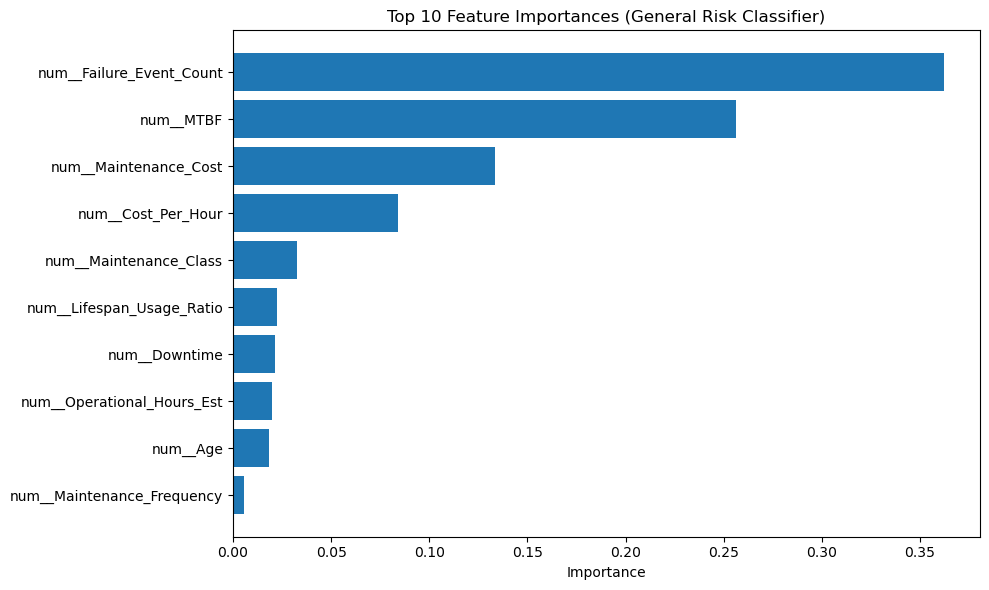

In [7]:
feature_names = preprocessor.get_feature_names_out()
importances = rf_classifier.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False)

print("Top Feature Importances (Why the model flags devices):")
display(importance_df.head(10))

plt.figure(figsize=(10, 6))
plot_df = importance_df.head(10).iloc[::-1]
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Top 10 Feature Importances (General Risk Classifier)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [8]:
os.makedirs("../artifacts", exist_ok=True)

# Save the full pipeline or components
joblib.dump(preprocessor, "../artifacts/rf_risk_preprocessor.joblib")
joblib.dump(rf_classifier, "../artifacts/rf_risk_classifier.joblib")

print("Saved artifacts/rf_risk_preprocessor.joblib")
print("Saved artifacts/rf_risk_classifier.joblib")
print("Model and preprocessor are ready for deployment!")


Saved artifacts/rf_risk_preprocessor.joblib
Saved artifacts/rf_risk_classifier.joblib
Model and preprocessor are ready for deployment!
